# foundations/01: CRN Basics and Gillespie SSA

This notebook introduces the core data structures of `crn_surrogate` and demonstrates the Gillespie stochastic simulation algorithm (SSA) on several reference chemical reaction networks.

**Contents:**
1. CRN Basics — stoichiometry, propensities, dependency matrices
2. Gillespie SSA: Birth-Death — ensemble simulation and stationary distribution check
3. Gillespie SSA: Lotka-Volterra — oscillations and phase portrait
4. Reference CRNs — gallery of all 5 library examples
5. Trajectory Interpolation — zero-order hold onto a regular time grid
6. Building TrajectoryItems — M trajectories per dataset item
7. Variance Analysis — birth-death Poisson variance check

In [1]:
import sys
from pathlib import Path

# Add notebooks root to path for shared utilities
sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style, plot_trajectory_ensemble
from crn_surrogate.simulation import GillespieSSA, Trajectory, O

setup_style()

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

ssa = GillespieSSA()

## 1. CRN Basics

A Chemical Reaction Network (CRN) is defined by:
- A set of **species** (molecular populations)
- A set of **reactions**, each with a **stoichiometry vector** (how populations change when the reaction fires) and a **propensity function** (rate at which the reaction occurs)

The `CRN` class stores the stoichiometry matrix `S` (n_reactions × n_species) and provides the `evaluate_propensities` method used by the simulator.

The **dependency matrix** indicates which species influence the rate of each reaction. It is derived from the propensity functions and is used by the bipartite GNN encoder.

In [2]:
from crn_surrogate.data.generation.reference_crns import birth_death
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

k1, k2 = 2.0, 0.5  # stationary mean = k1/k2 = 4
crn_bd = birth_death(k_birth=k1, k_death=k2)
crn_bd_repr = crn_to_tensor_repr(crn_bd)

print(crn_bd)
print(f"\nStoichiometry matrix (n_reactions x n_species):")
print(crn_bd.stoichiometry_matrix)
print(f"\nDependency matrix (n_reactions x n_species):")
print(crn_bd_repr.dependency_matrix)
print(f"\nPropensity type IDs: {crn_bd_repr.propensity_type_ids.tolist()}")
print(f"Propensity parameters: {crn_bd_repr.propensity_params}")

CRN(n_species=1, n_reactions=2, species=('A',))

Stoichiometry matrix (n_reactions x n_species):
tensor([[ 1.],
        [-1.]])

Dependency matrix (n_reactions x n_species):
tensor([[0.],
        [1.]])

Propensity type IDs: [2, 0]
Propensity parameters: tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])


## 2. Gillespie SSA: Birth-Death

The birth-death process is the simplest CRN:
- **Birth**: `∅ → A` at rate `k₁`
- **Death**: `A → ∅` at rate `k₂ · A`

The stationary distribution is `Poisson(k₁/k₂)`, so the mean and variance both equal `k₁/k₂ = 4`.

We use `simulate_ensemble` to run M independent trajectories and `plot_trajectory_ensemble` to visualize them.

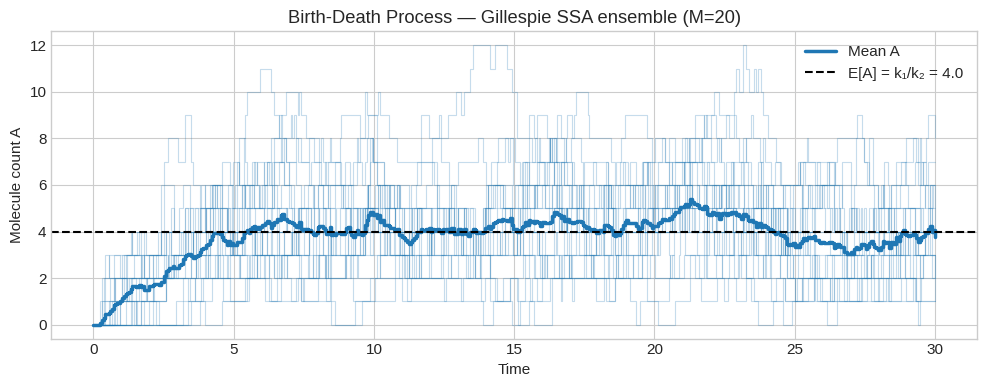

In [3]:
t_max = 30.0
time_grid = torch.linspace(0.0, t_max, 500)
states = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn_bd.stoichiometry_matrix,
        propensity_fn=crn_bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=t_max,
        n_trajectories=20,
        n_workers=1,
    ),
    time_grid,
).numpy()
t_grid = time_grid.numpy()
# states: (M, T, n_species)

fig, ax = plt.subplots(figsize=(10, 4))
plot_trajectory_ensemble(ax, t_grid, states, species_idx=0, color="tab:blue", label="Mean A")
ax.axhline(k1 / k2, color="black", linestyle="--", linewidth=1.5, label=f"E[A] = k₁/k₂ = {k1/k2}")
ax.set_xlabel("Time")
ax.set_ylabel("Molecule count A")
ax.set_title("Birth-Death Process — Gillespie SSA ensemble (M=20)")
ax.legend()
plt.tight_layout()
plt.show()

### Stationary distribution check

We sample many trajectories and collect final states. The empirical distribution should match `Poisson(k₁/k₂)`.

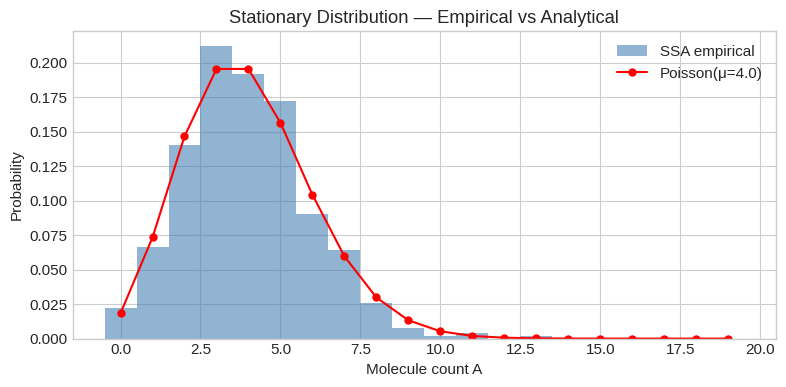

Empirical mean: 3.97  (expected: 4.0)
Empirical std:  1.97  (expected: 2.00)


In [4]:
from crn_surrogate.simulation import GillespieSSA

ssa = GillespieSSA()
n_samples = 500
final_counts = [
    ssa.simulate(
        stoichiometry=crn_bd.stoichiometry_matrix,
        propensity_fn=crn_bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=50.0,
    ).states[-1, 0].item()
    for _ in range(n_samples)
]
final_counts = np.array(final_counts, dtype=int)

mu = k1 / k2
x_vals = np.arange(0, 20)
poisson_pmf = poisson.pmf(x_vals, mu)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(final_counts, bins=np.arange(-0.5, 20.5), density=True, alpha=0.6,
        color="steelblue", label="SSA empirical")
ax.plot(x_vals, poisson_pmf, "ro-", markersize=5, label=f"Poisson(μ={mu})")
ax.set_xlabel("Molecule count A")
ax.set_ylabel("Probability")
ax.set_title("Stationary Distribution — Empirical vs Analytical")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Empirical mean: {np.mean(final_counts):.2f}  (expected: {mu})")
print(f"Empirical std:  {np.std(final_counts):.2f}  (expected: {np.sqrt(mu):.2f})")

## 3. Gillespie SSA: Lotka-Volterra

The Lotka-Volterra (predator-prey) system has two species and exhibits oscillatory dynamics:
- `A → 2A` (prey birth, rate k₁)
- `A + B → 2B` (predation, rate k₂)
- `B → ∅` (predator death, rate k₃)

The system exhibits sustained stochastic oscillations around a deterministic fixed point.

In [ ]:
from crn_surrogate.data.generation.reference_crns import lotka_volterra

crn_lv = lotka_volterra(k_prey_birth=1.0, k_predation=0.005, k_predator_death=0.6)
print(crn_lv)

time_grid_lv = torch.linspace(0.0, 50.0, 300)
states_lv = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn_lv.stoichiometry_matrix,
        propensity_fn=crn_lv.evaluate_propensities,
        initial_state=torch.tensor([100.0, 40.0]),
        t_max=50.0,
        n_trajectories=10,
        n_workers=1,
    ),
    time_grid_lv,
).numpy()
t_grid_lv = time_grid_lv.numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time series
plot_trajectory_ensemble(axes[0], t_grid_lv, states_lv, species_idx=0,
                         color="tab:blue", label="Mean Prey (A)")
plot_trajectory_ensemble(axes[0], t_grid_lv, states_lv, species_idx=1,
                         color="tab:orange", label="Mean Predator (B)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Molecule count")
axes[0].set_title("Lotka-Volterra — Time Series")
axes[0].legend()

# Phase portrait from a single long trajectory
traj_lv = ssa.simulate(
    stoichiometry=crn_lv.stoichiometry_matrix,
    propensity_fn=crn_lv.evaluate_propensities,
    initial_state=torch.tensor([100.0, 40.0]),
    t_max=50.0,
    max_reactions=500_000,
)
st = traj_lv.states.numpy()
axes[1].plot(st[:, 0], st[:, 1], alpha=0.5, linewidth=0.6, color="purple")
axes[1].scatter(st[0, 0], st[0, 1], color="green", s=60, zorder=5, label="Start")
axes[1].scatter(st[-1, 0], st[-1, 1], color="red", s=60, zorder=5, label="End")
axes[1].set_xlabel("Prey (A)")
axes[1].set_ylabel("Predator (B)")
axes[1].set_title("Lotka-Volterra — Phase Portrait")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Reference CRNs

The library provides five reference CRNs covering qualitatively different dynamics. Here we visualize one Gillespie trajectory for each.

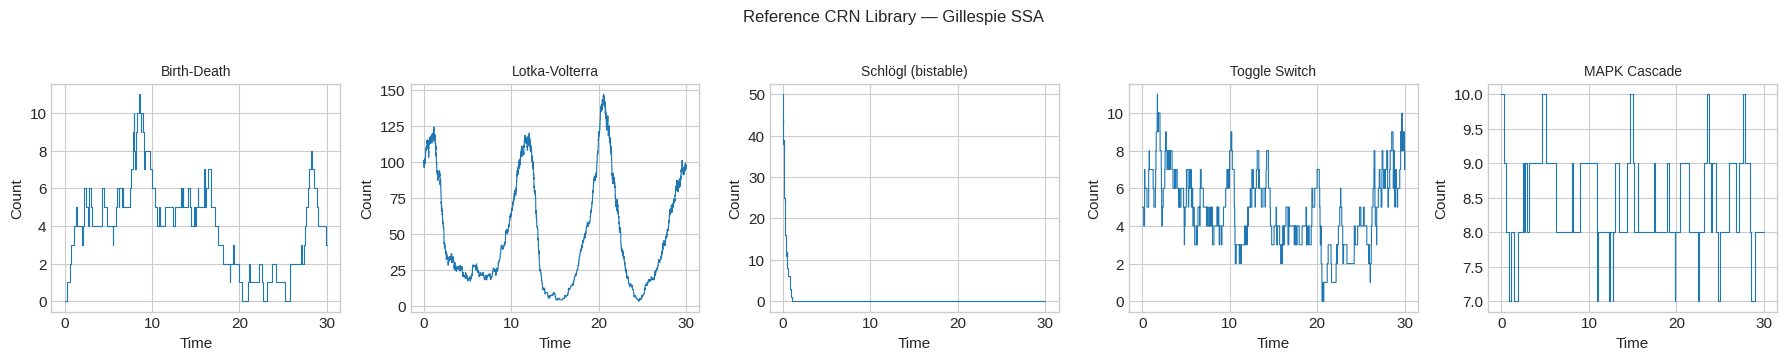

In [6]:
from crn_surrogate.data.generation.reference_crns import schlogl, toggle_switch, simple_mapk_cascade

reference_crns = [
    (birth_death(k_birth=2.0, k_death=0.5),       torch.tensor([0.0]),                          "Birth-Death"),
    (lotka_volterra(),                              torch.tensor([100.0, 40.0]),                  "Lotka-Volterra"),
    (schlogl(),                                     torch.tensor([50.0]),                         "Schl\u00f6gl (bistable)"),
    (toggle_switch(),                               torch.tensor([5.0, 5.0]),                     "Toggle Switch"),
    (simple_mapk_cascade(), torch.tensor([10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 100.0]),             "MAPK Cascade"),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, (crn, init, label) in zip(axes, reference_crns):
    traj = ssa.simulate(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init.clone(),
        t_max=30.0,
        max_reactions=200_000,
    )
    ax.step(traj.times.numpy(), traj.states[:, 0].numpy(), where="post", linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Time")
    ax.set_ylabel("Count")

plt.suptitle("Reference CRN Library — Gillespie SSA", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Trajectory Interpolation

The SSA produces events at exponentially distributed, irregular inter-event times. For training we interpolate onto a fixed grid using **zero-order hold** (piecewise constant), which is the correct interpolation for a jump process — the state is constant between events.

In [ ]:
T = 50
time_grid = torch.linspace(0.0, 20.0, T)

raw_traj = ssa.simulate(
    stoichiometry=crn_bd.stoichiometry_matrix,
    propensity_fn=crn_bd.evaluate_propensities,
    initial_state=torch.tensor([0.0]),
    t_max=20.0,
)
gridded = raw_traj.to_grid(time_grid)

print(f"Raw:     {raw_traj.n_steps} events at irregular times")
print(f"Gridded: {gridded.shape} on uniform grid of {T} points")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(raw_traj.times.numpy(), raw_traj.states[:, 0].numpy(),
        where="post", color="steelblue", alpha=0.5, linewidth=1.0, label="Raw SSA events")
ax.step(time_grid.numpy(), gridded[:, 0].numpy(),
        where="post", color="red", linewidth=2, linestyle="--", label="Gridded (ZOH)")
ax.scatter(time_grid.numpy(), gridded[:, 0].numpy(), color="red", s=18, zorder=5)
ax.set_xlabel("Time")
ax.set_ylabel("A(t)")
ax.set_title("Zero-Order Hold Interpolation")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Building TrajectoryItems

Each `TrajectoryItem` stores `trajectories: Tensor` of shape `(M, T, n_species)` — M independent SSA runs for the same (CRN, initial state) pair.

Having M trajectories per item allows the model to learn stochastic dynamics: the `VarianceMatchingLoss` compares `Var_pred[X(t)]` against `Var_true[X(t)]`, which requires M ≥ 2 samples to estimate empirical variance.

In [ ]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem

T_MAX = 20.0
N_GRID = 50
M = 16
time_grid = torch.linspace(0.0, T_MAX, N_GRID)

crn_configs = [
    (birth_death(k_birth=2.0, k_death=0.5), torch.tensor([0.0]),        "Birth-Death"),
    (lotka_volterra(),                       torch.tensor([80.0, 30.0]), "Lotka-Volterra"),
]

items = []
for crn_def, init, name in crn_configs:
    crn_repr = crn_to_tensor_repr(crn_def)
    for _ in range(5):
        trajs = Trajectory.stack_on_grid(
            ssa.simulate_batch(
                stoichiometry=crn_def.stoichiometry_matrix,
                propensity_fn=crn_def.evaluate_propensities,
                initial_state=init.clone(),
                t_max=T_MAX,
                n_trajectories=M,
                n_workers=1,
            ),
            time_grid,
        )
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init.clone(),
            trajectories=trajs,
            times=time_grid,
        ))
    print(f"  {name}: 5 items x {M} SSA runs = {5 * M} trajectories")

dataset = CRNTrajectoryDataset(items)
print(f"\nDataset: {len(dataset)} items")
print(f"trajectories shape per item: {items[0].trajectories.shape}  (M, T, n_species)")

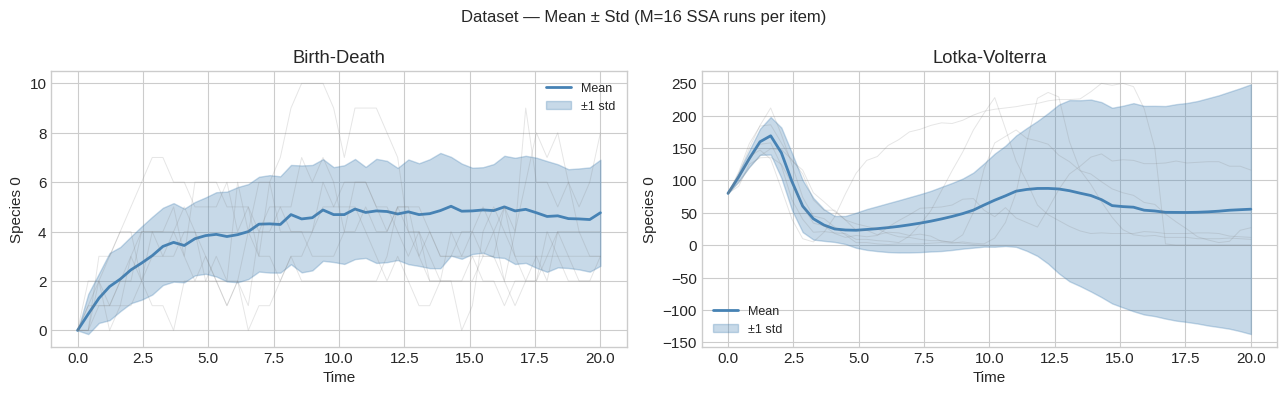

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (crn_def, init, name) in enumerate(crn_configs):
    crn_repr_check = crn_to_tensor_repr(crn_def)
    crn_items = [it for it in items if it.crn_repr.n_species == crn_def.n_species
                 and it.crn_repr.n_reactions == crn_def.n_reactions]
    all_trajs = torch.cat([it.trajectories[:, :, 0] for it in crn_items], dim=0)  # (N*M, T)
    mean_t = all_trajs.mean(dim=0).numpy()
    std_t = all_trajs.std(dim=0).numpy()
    t = time_grid.numpy()

    ax = axes[ax_idx]
    ax.plot(t, mean_t, color="steelblue", linewidth=2, label="Mean")
    ax.fill_between(t, mean_t - std_t, mean_t + std_t, alpha=0.3,
                    color="steelblue", label="\u00b11 std")
    for item in crn_items[:2]:
        for m in range(min(3, M)):
            ax.plot(t, item.trajectories[m, :, 0].numpy(),
                    color="gray", alpha=0.2, linewidth=0.7)
    ax.set_title(name)
    ax.set_xlabel("Time")
    ax.set_ylabel("Species 0")
    ax.legend(fontsize=9)

plt.suptitle(f"Dataset — Mean \u00b1 Std (M={M} SSA runs per item)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Variance Analysis

For the birth-death process the stationary distribution is Poisson(k₁/k₂), so both the mean and the variance should converge to k₁/k₂ = 4. This is a key sanity check: if the SSA is correct and we have enough trajectories, both moments must agree with the analytical value.

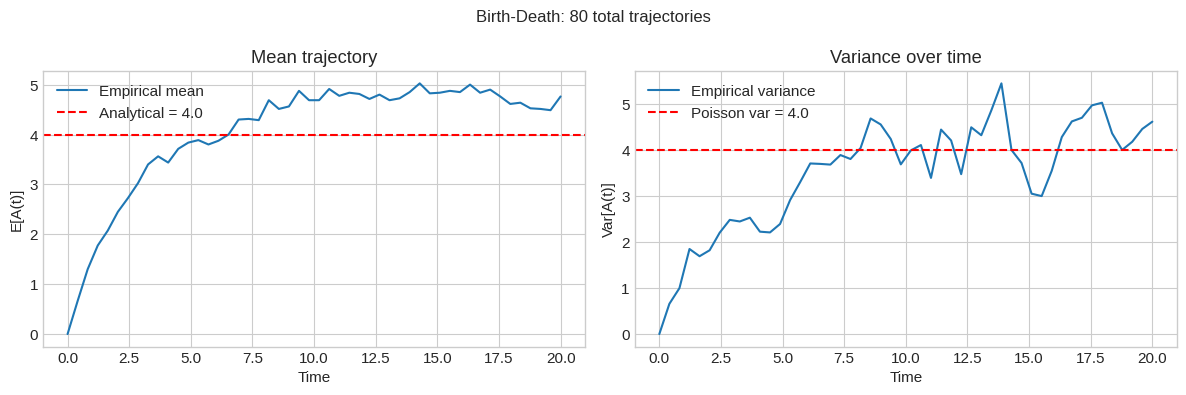

Converged mean (last 10): 4.70  (expected 4.0)
Converged var  (last 10): 4.52  (expected 4.0)


In [10]:
bd_items = [it for it in items
            if it.crn_repr.n_species == 1 and it.crn_repr.n_reactions == 2]

all_bd = torch.cat([it.trajectories[:, :, 0] for it in bd_items], dim=0)  # (N*M, T)
mean_t = all_bd.mean(dim=0).numpy()
var_t = all_bd.var(dim=0).numpy()
t = time_grid.numpy()
expected = k1 / k2  # 4.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, mean_t, label="Empirical mean")
axes[0].axhline(expected, color="red", linestyle="--", label=f"Analytical = {expected}")
axes[0].set_title("Mean trajectory")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("E[A(t)]")
axes[0].legend()

axes[1].plot(t, var_t, label="Empirical variance")
axes[1].axhline(expected, color="red", linestyle="--", label=f"Poisson var = {expected}")
axes[1].set_title("Variance over time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Var[A(t)]")
axes[1].legend()

plt.suptitle(f"Birth-Death: {len(all_bd)} total trajectories", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Converged mean (last 10): {mean_t[-10:].mean():.2f}  (expected {expected})")
print(f"Converged var  (last 10): {var_t[-10:].mean():.2f}  (expected {expected})")

## Summary

This notebook demonstrated:

- How to construct a CRN and inspect its stoichiometry and dependency matrices
- Running the Gillespie SSA and verifying the stationary distribution against the analytical Poisson result
- The Lotka-Volterra oscillations and phase portrait
- The five reference CRNs in the library
- Zero-order hold interpolation from irregular SSA event times to a regular grid
- Building `TrajectoryItem` objects with M independent trajectories per item
- Confirming that birth-death mean and variance converge to the Poisson analytical values